# Assessing a Model

In data science, a model is a set of assumptions about data. Often, models include assumptions about chance processes. In this section we assess whether a model is consistent with observed data using simulation.

In [1]:
import pandas as pd
%matplotlib inline
path_data = "../../../../assets/data/"
import matplotlib.pyplot as plt
plt.style.use("fivethirtyeight")
import numpy as np

## Jury Selection

This example examines whether the composition of a jury panel is consistent with random selection from an eligible population. At the time of Robert Swain's trial, 26% of eligible male jurors in Talladega County were Black, yet only 8 of 100 people on the jury panel were Black.

## A Model of Random Selection

One model is that the panel was selected at random from a population that was 26% Black and 74% non-Black. We will assess that model by simulation.

### The Statistic

Our statistic is the number of Black panelists in a panel of 100 people. Small values support the claim that Black residents were underrepresented.

In [2]:
sample_size = 100
eligible_population = [0.26, 0.74]

We first recreate the Data 8 function `sample_proportions` using NumPy.

In [3]:
def sample_proportions(sample_size, proportions):
    categories = np.arange(len(proportions))
    sample = np.random.choice(categories, size=sample_size, p=proportions)
    counts = np.bincount(sample, minlength=len(proportions))
    return counts / sample_size

The first entry of the result is the sample proportion of Black panelists.

In [4]:
sample_proportions(sample_size, eligible_population)[0]

np.float64(0.28)

We can convert that proportion to a count.

In [5]:
def one_simulated_count():
    return sample_size * sample_proportions(sample_size, eligible_population)[0]

### Simulating Multiple Values of the Statistic

In [6]:
counts = np.array([])
repetitions = 10000
for i in np.arange(repetitions):
    counts = np.append(counts, one_simulated_count())

## The Prediction Under the Model of Random Selection

The histogram below shows the distribution of counts predicted by the random-selection model.

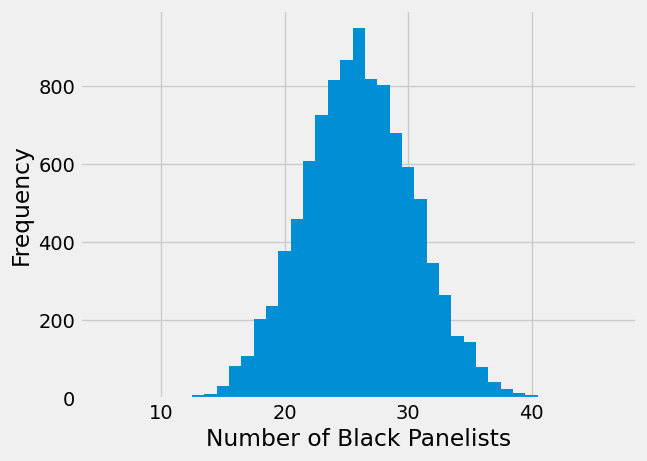

In [7]:
simulated_counts = pd.DataFrame({'Count in a Random Sample': counts})
simulated_counts['Count in a Random Sample'].plot.hist(bins=np.arange(5.5,46.6,1))
plt.xlabel('Number of Black Panelists')
plt.show()

Most simulated panels contain around 26 Black panelists, though there is natural variation.

## Comparing the Prediction and the Data

The actual panel contained only 8 Black panelists. The graph below marks that value with a red point.

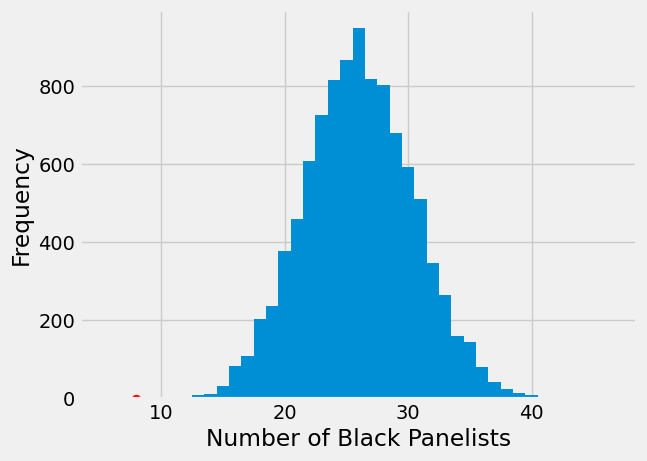

In [8]:
simulated_counts['Count in a Random Sample'].plot.hist(bins=np.arange(5.5,46.6,1))
plt.scatter(8,0,color='red',s=40)
plt.ylim(-0.002,None)
plt.xlabel('Number of Black Panelists')
plt.show()

The value 8 lies far in the left tail of the simulated distribution. Very few of the 10,000 simulated panels produced counts this small.

## Conclusion of the Data Analysis

If jurors had been selected at random from the eligible population, a panel with only 8 Black members out of 100 would be extremely unlikely. The simulation provides evidence against the model of random selection.

While such an outcome is not impossible, it is so unlikely under the model that the model is difficult to justify. The data are more consistent with a process that systematically underrepresented Black residents on jury panels.

## Statistical Bias

When a process produces errors or distortions that consistently operate in one direction, data scientists describe the process as biased. The simulation provides quantitative evidence that the jury-selection process was biased against Black panelists.

## Racial Bias

The statistical bias reflected broader racial bias in the legal system and society of the time. The process used to create jury rolls and select jurors systematically disadvantaged Black residents, contributing to underrepresentation on jury panels.

## Further Reading ##

Robert Swain was represented in the U.S. Supreme Court by [Constance Baker Motley](https://en.wikipedia.org/wiki/Constance_Baker_Motley), the first African-American woman to argue a case in that Court. She argued 10 cases in the Supreme Court and lost only one – Robert Swain's case in 1965.

[Thurgood Marshall](https://en.wikipedia.org/wiki/Thurgood_Marshall), who in 1967 became the first African-American Supreme Court Justice, had studied the Court's decision in Robert Swain's case and pressed for eliminating peremptory challenges that were based on race alone. This was achieved in the 1986 Supreme Court case [Batson v. Kentucky](https://supreme.justia.com/cases/federal/us/476/79/).

But Marshall had concerns about the efficacy of the Batson decision. He anticipated that some legal teams would circumvent it by finding ostensibly race-neutral ways to exclude Black jurors. In his [opinion](https://supreme.justia.com/cases/federal/us/476/79/#tab-opinion-1956655) concurring with the majority of the Court, he recommended going further and banning peremptory challenges altogether. His concluding words were, "I applaud the Court's holding that the racially discriminatory use of peremptory challenges violates the Equal Protection Clause, and I join the Court's opinion. However, only by banning peremptories entirely can such discrimination be ended." Thurgood Marshall's concerns were prescient, as you will see in some of the readings below.

In 2013, Constance Baker Motley was posthumously awarded a [Congressional gold medal](https://www.congress.gov/bill/113th-congress/house-bill/3097/text?r=5&s=1) "in recognition of her enduring contributions and service to the United States." In support of the award, members of the House of Representatives wrote, "Constance Baker Motley's only loss before the United States Supreme Court was in Swain v. Alabama, 380 U.S. 202 (1965), a case in which the Court refused to proscribe race-based peremptory challenges in cases involving African-American defendants and which was later reversed in Batson v. Kentucky, 476 U.S. 79 (1986), on grounds that had been largely asserted by Constance Baker Motley in the Swain case." 

Thurgood Marshall and Constance Baker Motley had other connections. For example, as a student at Columbia Law School, Baker Motley worked as a law clerk for Marshall. Some years later she wrote the original complaint in the landmark civil rights case Brown v. Board of Education in Topeka, which was won by Thurgood Marshall in 1954.

The [NAACP Legal Defense and Educational Fund](https://www.naacpldf.org/) argued Robert [Swain's case](https://www.naacpldf.org/press-release/ldf-marks-anniversary-of-batson-decision-reaffirms-importance-of-impartial-jury-selection/) and later supported the Batson case.

In spite of the Batson decision, racial bias in jury selection persists. Legal scholar and Berkeley Law School alum [Richard L. Harris Jr.](https://www.thehistorymakers.org/biography/robert-lewis-harris) has provided a [detailed account](https://scholarship.law.wm.edu/cgi/viewcontent.cgi?article=1944&context=wmlr) of the biases that are perpetuated by peremptory challenges.  

In their 2020 report [Whitewashing the Jury Box](http://www.clrc.ca.gov/CRPC/Pub/Panelist_Materials/PM-20210325-Semel.pdf): How California Perpetuates the Discriminatory Exclusion of Black and Latinx Jurors,
[Professor Elisabeth Semel](https://www.law.berkeley.edu/our-faculty/faculty-profiles/elisabeth-semel/) and co-authors in the Berkeley Law Death Penalty Clinic describe how Thurgood Marshall's concerns about the effectiveness of the Batson ruling are justified by experience in Californian courts.  

The U.S. Supreme Court [judgment](https://supreme.justia.com/cases/federal/us/380/202/) in the case Swain v. Alabama can be distressing to read. We have included it because some excerpts are quoted in the section. 